# AIMLC ZG521 — Conversational AI · Group Assignment 1
## Problem Statement 2 — Study of Embedding Models and Approximate Nearest Neighbor Search: Semantic Quality vs Search Efficiency

**Group 129**


## Student Details

> **Complete this table with the actual group information before submission.**

| Name | BITS ID | Email |
|---|---|---|
| Member 1 — enter name | Enter BITS ID | Enter email |
| Member 2 — enter name | Enter BITS ID | Enter email |
| Member 3 — enter name | Enter BITS ID | Enter email |
| Member 4 — enter name | Enter BITS ID | Enter email |


## Group Contributions

> Replace the member labels below with the actual names and retain one or more specific contributions for every member.

| Student | Contribution area | Specific contribution |
|---|---|---|
| Member 1 | Dataset and embedding | Dataset loading, validation, and embedding generation |
| Member 2 | Similarity and exact kNN | Metric formulas, normalization analysis, and exact retrieval |
| Member 3 | HNSW and IVF | FAISS index construction and ANN parameter sweeps |
| Member 4 | Evaluation and reporting | Metrics, visualizations, qualitative examples, and report preparation |

## Architecture and Workflow

The workflow uses the same corpus, query set, identifiers, normalized vectors, and qrels for every comparison. Documents are encoded offline; queries are encoded at search time. Exact cosine kNN provides ground truth, while HNSW and IVF approximate the same inner-product search space. Retrieval quality is measured with qrels and efficiency is measured using latency, speedup, and candidate-vector estimates.

```text
SciFact corpus + queries + qrels
              |
      Validate and align IDs
              |
   +----------+-----------+
   |                      |
Encoder 1              Encoder 2
DistilBERT             BGE-large
   |                      |
Normalized vectors   Normalized vectors
   |                      |
   +----------+-----------+
              |
 Exact kNN / HNSW / IVF
              |
 Recall@5, latency, speedup,
 candidate estimates, examples
              |
       Final recommendation
```

Figure 1. Experimental workflow for the embedding and ANN comparison.


## Problem Statement
,
,Study of embedding models and approximate nearest neighbor (ANN) search, comparing **semantic quality vs search efficiency**:
,- **Module 1** — Dataset and embedding preparation 
,- **Module 2** — Similarity metrics and exact retrieval (3 marks)
,- **Module 3** — ANN search experiment: HNSW vs IVF (3 marks)
,- **Module 4** — Embedding quality analysis and final recommendation (3 marks)


## Tools and Libraries Used

- **Python 3.10**
- `datasets` (Hugging Face) — loading the BEIR-format retrieval dataset
- `pandas`, `numpy` — data handling
- `sentence-transformers` — encoder embedding models (Task 2 onward)
- `faiss-cpu` — HNSW / IVF ANN indexes (Task 5 onward)
- `matplotlib` — plots (Task 6 onward)

Install all of the above with: `pip install -r requirements.txt` (see `ass-1/requirements.txt`).


In [23]:
# Purpose: environment setup. Trusts the OS cert store and routes
# through the corporate proxy (fixes SSL errors on office/lab networks), then
# imports libraries and defines two reuse helpers used later: resolve_model()
# (use a local model copy if one exists, else download) and
# load_aligned_embeddings() (load saved embeddings, reordered by id).
import os

try:
    import truststore
    truststore.inject_into_ssl()
except Exception:
    pass  # fine if unavailable -- only needed behind an SSL-inspecting proxy

import urllib.request
_proxy = urllib.request.getproxies().get("https") or urllib.request.getproxies().get("http")
if _proxy:
    os.environ["HTTP_PROXY"] = os.environ["HTTPS_PROXY"] = _proxy
    os.environ["http_proxy"] = os.environ["https_proxy"] = _proxy

import sys, time, json, random
import numpy as np
import pandas as pd

random.seed(129)   # Group 129 -- fixed seed for reproducibility
np.random.seed(129)


def resolve_model(model_name):
    """Return a local model path, downloading it into models/ when needed."""
    os.makedirs("models", exist_ok=True)
    local = os.path.join("models", model_name.split("/")[-1])
    if os.path.isdir(local) and os.path.exists(os.path.join(local, "config.json")):
        print(f"[info] Using cached model: {local}/")
        return local

    try:
        from huggingface_hub import snapshot_download
        print(f"[info] Downloading {model_name} into {local}/ ...")
        snapshot_download(
            repo_id=model_name,
            local_dir=local,
            local_dir_use_symlinks=False
        )
        print(f"[info] Model cached in {local}/")
        return local
    except Exception as exc:
        # SentenceTransformer can still use its standard Hugging Face cache.
        print(f"[warning] Could not cache {model_name} locally: {exc!r}")
        print("[info] Falling back to the Hugging Face model ID.")
        return model_name


def load_aligned_embeddings(emb_path, id_path, wanted_ids):
    """Load a saved embedding array, reordered to match wanted_ids (via the
    id file saved alongside it), so row order never has to be assumed."""
    emb = np.load(emb_path)
    if os.path.exists(id_path):
        saved_ids = [str(x) for x in json.load(open(id_path))]
        pos = {sid: i for i, sid in enumerate(saved_ids)}
        emb = emb[[pos[str(w)] for w in wanted_ids]]
    return emb


print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy :", np.__version__)


Python: 3.14.5
pandas: 3.0.5
numpy : 2.5.2


---
,# Task 1 — Corpus and Query Dataset Preparation 
,
,**Dataset chosen: `SciFact`** (BEIR benchmark; Thakur et al., 2021 / Wadden et al., 2020) — a publicly available dataset that ships a document corpus, a query set, and query-document relevance labels together, matching this task's requirement exactly. Corpus (~5,183 passages) and queries (~300) both clear the 1,000/50 minimums.


In [24]:
# Purpose: load SciFact (corpus/queries/qrels). Uses the local
# data/raw/ copy if present (no network needed -- works behind a proxy that
# blocks the Hub); otherwise downloads from Hugging Face. Queries are then
# filtered to only those with a relevance judgment.
import os
import pandas as pd

RAW_FILES = ("corpus.jsonl", "queries.jsonl", "qrels.tsv")


def _find_data_raw():
    """First data/raw directory (checked relative to cwd, then one level up)
    that already contains all three raw files, or None."""
    for base in (os.path.join("data", "raw"), os.path.join("..", "data", "raw"),
                 os.path.join("ass-1", "data", "raw")):
        if all(os.path.exists(os.path.join(base, f)) for f in RAW_FILES):
            return base
    return None


def load_beir_scifact():
    """Load SciFact from local data/raw if present, else the Hugging Face
    Hub. Queries are filtered to those with >=1 relevance judgment."""
    local_dir = _find_data_raw()
    if local_dir is not None:
        corpus_df = pd.read_json(os.path.join(local_dir, "corpus.jsonl"), lines=True)
        queries_df = pd.read_json(os.path.join(local_dir, "queries.jsonl"), lines=True)
        qrels_df = pd.read_csv(os.path.join(local_dir, "qrels.tsv"), sep="\t")
        # Standard BEIR files use _id/query-id/corpus-id/score; the rest of
        # this notebook uses explicit, stable names.
        corpus_df = corpus_df.rename(columns={"_id": "doc_id", "corpus-id": "doc_id"})
        queries_df = queries_df.rename(columns={"_id": "query_id", "query-id": "query_id"})
        qrels_df = qrels_df.rename(columns={
            "query-id": "query_id", "corpus-id": "doc_id", "score": "relevance"
        })
        print(f"[info] Loaded SciFact from local files: {local_dir}/")
    else:
        from datasets import load_dataset
        corpus_df = load_dataset("BeIR/scifact", "corpus", split="corpus").to_pandas().rename(columns={"_id": "doc_id"})
        queries_df = load_dataset("BeIR/scifact", "queries", split="queries").to_pandas().rename(columns={"_id": "query_id"})
        qrels_df = load_dataset("BeIR/scifact-qrels", split="test").to_pandas()
        qrels_df.columns = ["query_id", "doc_id", "relevance"]
        print("[info] Downloaded SciFact from the Hugging Face Hub.")

    # IDs must be strings on both sides, or later merges/lookups silently fail
    corpus_df["doc_id"] = corpus_df["doc_id"].astype(str)
    queries_df["query_id"] = queries_df["query_id"].astype(str)
    qrels_df["query_id"] = qrels_df["query_id"].astype(str)
    qrels_df["doc_id"] = qrels_df["doc_id"].astype(str)

    # Keep only queries with >=1 relevance judgment (standard BEIR practice)
    labelled_ids = set(qrels_df["query_id"].unique())
    before = len(queries_df)
    queries_df = queries_df[queries_df["query_id"].isin(labelled_ids)].reset_index(drop=True)
    if before - len(queries_df):
        print(f"[info] Dropped {before - len(queries_df)} queries with no relevance judgment "
              f"(kept {len(queries_df)}, all with >=1 qrel).")

    # Cache a first-time internet download so later runs work offline.
    if local_dir is None:
        cache_dir = os.path.join("data", "raw")
        os.makedirs(cache_dir, exist_ok=True)
        corpus_df.to_json(os.path.join(cache_dir, "corpus.jsonl"), orient="records", lines=True)
        queries_df.to_json(os.path.join(cache_dir, "queries.jsonl"), orient="records", lines=True)
        qrels_df.to_csv(os.path.join(cache_dir, "qrels.tsv"), sep="\t", index=False)
        print(f"[info] Cached downloaded SciFact files in {cache_dir}/")

    return corpus_df, queries_df, qrels_df


corpus_df, queries_df, qrels_df = load_beir_scifact()
DATA_DIR = _find_data_raw() or os.path.join("data", "raw")
print(f"corpus  : {len(corpus_df)} passages")
print(f"queries : {len(queries_df)} queries (all with >=1 relevance judgment)")
print(f"qrels   : {len(qrels_df)} relevance judgments")


[info] Loaded SciFact from local files: data\raw/
corpus  : 5183 passages
queries : 300 queries (all with >=1 relevance judgment)
qrels   : 339 relevance judgments


In [25]:
# Purpose: check the loaded data against the assignment's stated
# minimums (>=1,000 passages, >=50 queries, every query labelled) and stop
# the notebook immediately (via assert) if either minimum isn't met.
MIN_CORPUS, MIN_QUERIES = 1000, 50

meets_corpus_min = len(corpus_df) >= MIN_CORPUS
meets_query_min = len(queries_df) >= MIN_QUERIES

print(f"Corpus  >= {MIN_CORPUS}: {meets_corpus_min}  ({len(corpus_df)} passages)")
print(f"Queries >= {MIN_QUERIES}: {meets_query_min}  ({len(queries_df)} queries)")
print(f"Every query has >=1 relevance judgment: "
      f"{queries_df['query_id'].isin(qrels_df['query_id']).all()}")

assert meets_corpus_min, "Corpus below the 1,000-passage minimum"
assert meets_query_min, "Query set below the 50-query minimum"
print("\n[OK] SciFact data clears both minimums.")


Corpus  >= 1000: True  (5183 passages)
Queries >= 50: True  (300 queries)
Every query has >=1 relevance judgment: True

[OK] SciFact data clears both minimums.


In [26]:
# Purpose: print one example row from each of the three tables
# (corpus, queries, qrels) so the schema is visible before it's used later.
print("=== Sample corpus passage ===")
print(corpus_df.iloc[0].to_dict())

print("\n=== Sample query ===")
print(queries_df.iloc[0].to_dict())

print("\n=== Sample relevance judgments (qrels) ===")
print(qrels_df.head())


=== Sample corpus passage ===
{'doc_id': '4983', 'title': 'Microstructural development of human newborn cerebral white matter assessed in vivo by diffusion tensor magnetic resonance imaging.', 'text': 'Alterations of the architecture of cerebral white matter in the developing human brain can affect cortical development and result in functional disabilities. A line scan diffusion-weighted magnetic resonance imaging (MRI) sequence with diffusion tensor analysis was applied to measure the apparent diffusion coefficient, to calculate relative anisotropy, and to delineate three-dimensional fiber architecture in cerebral white matter in preterm (n = 17) and full-term infants (n = 7). To assess effects of prematurity on cerebral white matter development, early gestation preterm infants (n = 10) were studied a second time at term. In the central white matter the mean apparent diffusion coefficient at 28 wk was high, 1.8 microm2/ms, and decreased toward term to 1.2 microm2/ms. In the posterior 

In [27]:
# Purpose: write corpus/queries/qrels to the resolved data/raw
# directory (DATA_DIR, set in the load cell above) so Tasks 2+ can load the
# exact same fixed dataset without re-downloading or re-running this cell.
import os

# Reuse the directory resolved in the load cell; default to ./data/raw if this
# cell is ever run on its own.
DATA_DIR = globals().get("DATA_DIR", os.path.join("data", "raw"))
os.makedirs(DATA_DIR, exist_ok=True)

corpus_df.to_json(os.path.join(DATA_DIR, "corpus.jsonl"), orient="records", lines=True)
queries_df.to_json(os.path.join(DATA_DIR, "queries.jsonl"), orient="records", lines=True)
qrels_df.to_csv(os.path.join(DATA_DIR, "qrels.tsv"), sep="\t", index=False)

print(f"Saved to {DATA_DIR}/: corpus.jsonl, queries.jsonl, qrels.tsv")


Saved to data\raw/: corpus.jsonl, queries.jsonl, qrels.tsv


### Dataset Details and Source

- **Name:** SciFact (BEIR benchmark; biomedical / scientific-claim verification)
- **Citation:** Wadden et al., *Fact or Fiction: Verifying Scientific Claims*, EMNLP 2020; redistributed by Thakur et al., *BEIR*, NeurIPS 2021
- **Source:** https://huggingface.co/datasets/BeIR/scifact (corpus + queries), https://huggingface.co/datasets/BeIR/scifact-qrels (relevance judgments)
- **Size:** 5,183 corpus passages, 300 queries (each with ≥1 relevance judgment), binary relevance
- **Format:** corpus = `{doc_id, title, text}`; queries = `{query_id, text}`; qrels = `{query_id, doc_id, relevance}`

### Explanation of the Logic Used

`load_beir_scifact()` downloads corpus/queries/qrels from Hugging Face and normalizes IDs to a common schema. Queries are filtered to only those with a qrel — the raw split ships 1,109 queries but just 300 have a relevance judgment, so filtering makes "relevance information for each query" literally true.

### Justification for the Chosen Approach

The assignment explicitly permits "an existing dataset containing query-document relevance labels" — BEIR datasets bundle exactly that, avoiding hand-built (and inconsistent) relevance judgments. SciFact's claim-verification domain gives clean, unambiguous labels, useful later for Task 3/7.

### Inference

Corpus and queries clear the assignment minimums by ~5x and ~6x respectively, leaving room to subsample later if needed. The 809 dropped queries simply have no qrel in this split — expected, not a data quality issue.


---
,# Task 2 — Embedding Generation and Pooling 
,
,**Two encoder models, chosen for contrasting profiles:**
,
,1. `distilbert-base-uncased` (Sanh et al., 2019) — general-purpose distilled BERT, **mean pooling**, not fine-tuned for retrieval.
,2. `BAAI/bge-large-en-v1.5` (Xiao et al., 2023) — trained specifically for retrieval via contrastive fine-tuning, **[CLS]-token pooling**.
,
,## Why encoder models are appropriate
,
,Encoder-only transformers use bidirectional self-attention — every token's representation draws on *both* directions of context — and pooling those representations yields one fixed-length vector summarizing the whole input's meaning. That's exactly what semantic retrieval needs: query and document mapped into a shared space where "similar meaning" becomes "small distance." Decoder-only models, by contrast, are causal (one-directional) and have no single hidden state that naturally summarizes a full sequence, making them a worse fit for embedding generation.


In [28]:
# Purpose: for each model, record documented facts (dimension,
# pooling, max length), then embed the corpus + queries. Saves embeddings to
# data/results/ and reuses them on later runs (no model/network needed once
# generated). Records execution status without fabricating results when a model is unavailable.
import os, json, time
import numpy as np
import pandas as pd

MODEL_SPECS = {
    "distilbert-base-uncased": {"pooling": "mean pooling", "dim": 768, "max_input_length": 512},
    "BAAI/bge-large-en-v1.5": {"pooling": "[CLS] token pooling", "dim": 1024, "max_input_length": 512},
}

os.makedirs("data/results", exist_ok=True)
corpus_texts = corpus_df["text"].tolist()
query_texts = queries_df["text"].tolist()

TIMINGS_PATH = "data/results/task2_timings.json"
timings = json.load(open(TIMINGS_PATH)) if os.path.exists(TIMINGS_PATH) else {}

comparison_rows = []
for model_name, spec in MODEL_SPECS.items():
    print(f"=== {model_name} ===")
    safe = model_name.replace("/", "__")
    doc_path = f"data/results/embeddings_{safe}.npy"
    qry_path = f"data/results/query_embeddings_{safe}.npy"
    elapsed = None

    if os.path.exists(doc_path) and os.path.exists(qry_path):
        doc_emb = load_aligned_embeddings(doc_path, "data/results/doc_ids.json", corpus_df["doc_id"])
        qry_emb = load_aligned_embeddings(qry_path, "data/results/query_ids.json", queries_df["query_id"])
        saved_timing = timings.get(model_name)
        elapsed = (saved_timing.get("documents_s") if isinstance(saved_timing, dict) else saved_timing)
        print(f"  Loaded saved embeddings: docs={doc_emb.shape}, queries={qry_emb.shape}")
    else:
        try:
            from sentence_transformers import SentenceTransformer
            model = SentenceTransformer(resolve_model(model_name))
            t0 = time.time()
            doc_emb = model.encode(corpus_texts, show_progress_bar=True, batch_size=64)
            doc_elapsed = time.perf_counter() - t0
            t1 = time.perf_counter()
            qry_emb = model.encode(query_texts, show_progress_bar=True, batch_size=64)
            qry_elapsed = time.perf_counter() - t1
            elapsed = doc_elapsed
            np.save(doc_path, doc_emb)
            np.save(qry_path, qry_emb)
            with open("data/results/doc_ids.json", "w", encoding="utf-8") as f:
                json.dump(corpus_df["doc_id"].astype(str).tolist(), f)
            with open("data/results/query_ids.json", "w", encoding="utf-8") as f:
                json.dump(queries_df["query_id"].astype(str).tolist(), f)
            timings[model_name] = {"documents_s": round(doc_elapsed, 2), "queries_s": round(qry_elapsed, 2)}
            json.dump(timings, open(TIMINGS_PATH, "w"), indent=2)
            print(f"  Generated + saved: docs={doc_emb.shape}, queries={qry_emb.shape}, time={elapsed:.1f}s")
        except Exception as e:
            print(f"  [warning] Could not run this model here: {e!r}")
            print("  Fix: install sentence-transformers + internet access, then re-run.")

    # Persist alignment metadata for both freshly generated and cached arrays.
    with open("data/results/doc_ids.json", "w", encoding="utf-8") as f:
        json.dump(corpus_df["doc_id"].astype(str).tolist(), f)
    with open("data/results/query_ids.json", "w", encoding="utf-8") as f:
        json.dump(queries_df["query_id"].astype(str).tolist(), f)

    comparison_rows.append({
        "Model name": model_name,
        "Embedding dimension": spec["dim"],
        "Max/typical input length (tokens)": spec["max_input_length"],
        "Pooling strategy": spec["pooling"],
        "Approx. document embedding time (s)": round(float(elapsed), 2) if elapsed is not None else None,
        "Timing status": "Executed" if elapsed is not None else "Execution required before submission",
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


=== distilbert-base-uncased ===
  Loaded saved embeddings: docs=(5183, 768), queries=(300, 768)
=== BAAI/bge-large-en-v1.5 ===
  Loaded saved embeddings: docs=(5183, 1024), queries=(300, 1024)


,Model name,Embedding dimension,Max/typical input length (tokens),Pooling strategy,Approx. document embedding time (s),Timing status
0,distilbert-base-uncased,768,512,mean pooling,298.93,Executed
1,BAAI/bge-large-en-v1.5,1024,512,[CLS] token pooling,4423.52,Executed


### Explanation of the Logic Used

Model name, dimension, max input length, and pooling strategy are documented facts from each model's official card (`MODEL_SPECS`) — no execution needed. Only the embeddings and timing require real execution, so the loop attempts that per model and records whether execution completed and requires real timings before submission.

### Justification for the Chosen Models

DistilBERT and BGE-large differ on exactly the axis this problem statement asks about: DistilBERT is smaller/faster and general-purpose, BGE-large is larger/slower and purpose-built for retrieval — and they use different pooling strategies (mean vs `[CLS]`), which is itself a required "for each model, document..." item. This gives Task 7 a real, explainable axis of disagreement rather than two near-identical models.

### Inference

BGE-large's larger dimension (1024 vs 768) and contrastive/RetroMAE training are expected to separate semantically related and unrelated passages more cleanly than DistilBERT — the concrete evidence for this is Task 7's side-by-side comparison, not asserted here.


---
,# Task 3 — Similarity Metric Comparison 
,
,**Model used: `BAAI/bge-large-en-v1.5`** — the retrieval-purpose-built model from Task 2, so the metric comparison reflects an embedding space actually optimized for semantic search (DistilBERT's general-purpose space would make this a less meaningful comparison).
,
,**Pair selection (25 pairs, ≥20 required):** 5 randomly sampled queries × 5 candidate documents each (the true relevant document from `qrels`, plus 4 random distractors) — enough per query to compare *rankings*, not just isolated scores.


In [29]:
# Purpose: implement the three similarity/distance metrics
# directly from their mathematical definitions (not by calling an opaque
# library function), so the formulas are visible and auditable.
import numpy as np

def cosine_similarity(a, b):
    """cos(theta) = (a . b) / (||a|| * ||b||)"""
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

def dot_product(a, b):
    """a . b = sum_i a_i * b_i"""
    return float(np.dot(a, b))

def l2_distance(a, b):
    """||a - b||_2 = sqrt(sum_i (a_i - b_i)^2)"""
    return float(np.linalg.norm(a - b))

print("[OK] Cosine, dot-product, and L2 formulas are defined for the metric experiment.")


[OK] Cosine, dot-product, and L2 formulas are defined for the metric experiment.


In [30]:
# Purpose: build the 25 query-document pairs used for Task 3.
# For each of 5 randomly sampled queries, pair it with its one true relevant
# document (from qrels) plus 4 random "distractor" documents -- so each
# query has a small ranked set of candidates to compare metrics across.
import random
random.seed(129)

MODEL_FOR_TASK3 = "BAAI/bge-large-en-v1.5"
N_QUERIES, N_DISTRACTORS = 5, 4

sample_queries = queries_df.sample(n=N_QUERIES, random_state=129).reset_index(drop=True)
all_doc_ids = corpus_df["doc_id"].tolist()

pairs = []
for _, q in sample_queries.iterrows():
    qid, qtext = q["query_id"], q["text"]

    # Include all known relevant documents and sample only non-relevant distractors.
    relevant_ids = set(
        qrels_df.loc[qrels_df["query_id"] == qid, "doc_id"].astype(str)
    )
    distractor_pool = [d for d in all_doc_ids if d not in relevant_ids]
    distractors = random.sample(
        distractor_pool, min(N_DISTRACTORS, len(distractor_pool))
    )
    doc_ids_for_query = list(relevant_ids) + distractors

    for did in doc_ids_for_query:
        text = corpus_df.loc[corpus_df["doc_id"] == did, "text"].values[0]
        pairs.append({"query_id": qid, "query_text": qtext, "doc_id": did,
                      "doc_text": text, "is_relevant": did in relevant_ids})

pairs_df = pd.DataFrame(pairs)
print(f"Selected {len(pairs_df)} query-document pairs across {pairs_df['query_id'].nunique()} "
      f"queries (>= 20 required).")


Selected 25 query-document pairs across 5 queries (>= 20 required).


In [31]:
# Purpose: get an embedding for each pair's query/document, then
# compute cosine, dot product, and L2 for every pair. Reuses Task 2's saved
# embeddings for MODEL_FOR_TASK3 if they exist (no model/network needed);
# otherwise embeds the 25 pairs directly.
import os
import numpy as np
import pandas as pd

_safe = MODEL_FOR_TASK3.replace("/", "__")
_doc_path = f"data/results/embeddings_{_safe}.npy"
_qry_path = f"data/results/query_embeddings_{_safe}.npy"
metrics_df = q_emb = d_emb = None


def _compute_metrics(q_emb, d_emb):
    rows = []
    for i in range(len(pairs_df)):
        a, b = q_emb[i], d_emb[i]
        rows.append({
            "query_id": pairs_df.loc[i, "query_id"],
            "doc_id": pairs_df.loc[i, "doc_id"],
            "is_relevant": pairs_df.loc[i, "is_relevant"],
            "cosine": cosine_similarity(a, b),
            "dot_product": dot_product(a, b),
            "l2_distance": l2_distance(a, b),
        })
    return pd.DataFrame(rows)


if os.path.exists(_doc_path) and os.path.exists(_qry_path):
    doc_emb_all = load_aligned_embeddings(_doc_path, "data/results/doc_ids.json", corpus_df["doc_id"])
    qry_emb_all = load_aligned_embeddings(_qry_path, "data/results/query_ids.json", queries_df["query_id"])
    doc_idx = {d: i for i, d in enumerate(corpus_df["doc_id"].tolist())}
    qry_idx = {q: i for i, q in enumerate(queries_df["query_id"].tolist())}
    q_emb = np.stack([qry_emb_all[qry_idx[pairs_df.loc[i, "query_id"]]] for i in range(len(pairs_df))])
    d_emb = np.stack([doc_emb_all[doc_idx[pairs_df.loc[i, "doc_id"]]] for i in range(len(pairs_df))])
    metrics_df = _compute_metrics(q_emb, d_emb)
    print(f"Reused saved {MODEL_FOR_TASK3} embeddings for {len(metrics_df)} pairs.")
    display(metrics_df)
else:
    try:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer(resolve_model(MODEL_FOR_TASK3))
        q_emb = model.encode(pairs_df["query_text"].tolist(), show_progress_bar=True)
        d_emb = model.encode(pairs_df["doc_text"].tolist(), show_progress_bar=True)
        metrics_df = _compute_metrics(q_emb, d_emb)
        print(f"Computed cosine/dot/L2 for {len(metrics_df)} pairs using {MODEL_FOR_TASK3}.")
        display(metrics_df)
    except Exception as e:
        print(f"[warning] Could not run {MODEL_FOR_TASK3} here: {e!r}")
        print("Run Task 2 first to create saved embeddings, then re-run this cell.")


Reused saved BAAI/bge-large-en-v1.5 embeddings for 25 pairs.


,query_id,doc_id,is_relevant,cosine,dot_product,l2_distance
0,660,1215116,True,0.613863,0.613863,0.878792
1,660,41496215,False,0.407035,0.407035,1.089004
2,660,32177659,False,0.447672,0.447672,1.051026
3,660,13702924,False,0.500359,0.500359,0.999641
4,660,2048139,False,0.525342,0.525342,0.974329
5,1362,8290953,True,0.584091,0.584090,0.912041
6,1362,22025252,False,0.489939,0.489939,1.010011
7,1362,154763124,False,0.441601,0.441601,1.056787
8,1362,10795340,False,0.477080,0.477080,1.022663
9,1362,17119869,False,0.498330,0.498330,1.001668


In [32]:
# Purpose: two checks required by Task 3.
#   1) Ranking comparison -- for each query, does sorting its 5 candidate
#      docs by cosine give the same order as sorting by dot product / L2?
#      Also prints the raw embedding norms, since dot product only diverges
#      from cosine when vector norms actually vary across documents.
#   2) Normalization effect -- re-normalize the same embeddings to unit
#      length and confirm the textbook identities: dot(a,b) == cosine(a,b)
#      and ||a-b||^2 == 2 - 2*cosine(a,b) once vectors have length 1.
if metrics_df is not None:
    doc_norms = np.linalg.norm(d_emb, axis=1)
    print(f"Raw document embedding norms: mean={doc_norms.mean():.4f}, std={doc_norms.std():.4f} "
          f"(dot product can only disagree with cosine if this std is non-trivial)\n")

    print("=== Ranking comparison per query (raw, unnormalized embeddings) ===")
    n_changed = 0
    for qid, group in metrics_df.groupby("query_id"):
        cos_rank = group.sort_values("cosine", ascending=False)["doc_id"].tolist()
        dot_rank = group.sort_values("dot_product", ascending=False)["doc_id"].tolist()
        l2_rank = group.sort_values("l2_distance", ascending=True)["doc_id"].tolist()  # smaller distance = closer
        changed = not (cos_rank == dot_rank == l2_rank)
        n_changed += changed
        print(f"query {qid}: cosine==dot ranking? {cos_rank == dot_rank}  |  "
              f"cosine==L2 ranking? {cos_rank == l2_rank}")
    print(f"Summary: ranking changed across metrics for {n_changed}/{metrics_df['query_id'].nunique()} queries.\n")

    print("=== Normalization effect: recompute dot/L2 on unit-normalized embeddings ===")
    def normalize(v):
        return v / np.linalg.norm(v)

    norm_rows = []
    for i in range(len(pairs_df)):
        a, b = normalize(q_emb[i]), normalize(d_emb[i])
        norm_rows.append({
            "query_id": pairs_df.loc[i, "query_id"],
            "doc_id": pairs_df.loc[i, "doc_id"],
            "dot_normalized": dot_product(a, b),
            "l2_normalized": l2_distance(a, b),
        })
    norm_df = pd.DataFrame(norm_rows).merge(
        metrics_df[["query_id", "doc_id", "cosine"]], on=["query_id", "doc_id"])
    # These two columns should both end up all-True -- that's the mathematical
    # identity for unit-normalized vectors, verified here on real numbers
    norm_df["dot_matches_cosine"] = np.isclose(norm_df["dot_normalized"], norm_df["cosine"], atol=1e-4)
    norm_df["l2sq_matches_2_minus_2cos"] = np.isclose(
        norm_df["l2_normalized"] ** 2, 2 - 2 * norm_df["cosine"], atol=1e-4)
    display(norm_df[["query_id", "doc_id", "dot_matches_cosine", "l2sq_matches_2_minus_2cos"]])
    print(f"Summary: identity held for {norm_df['dot_matches_cosine'].sum()}/{len(norm_df)} pairs (dot) "
          f"and {norm_df['l2sq_matches_2_minus_2cos'].sum()}/{len(norm_df)} pairs (L2).")
else:
    print("Skipped -- needs metrics_df from the cell above (requires live model access).")


Raw document embedding norms: mean=1.0000, std=0.0000 (dot product can only disagree with cosine if this std is non-trivial)

=== Ranking comparison per query (raw, unnormalized embeddings) ===
query 1359: cosine==dot ranking? True  |  cosine==L2 ranking? True
query 1362: cosine==dot ranking? True  |  cosine==L2 ranking? True
query 185: cosine==dot ranking? True  |  cosine==L2 ranking? True
query 660: cosine==dot ranking? True  |  cosine==L2 ranking? True
query 743: cosine==dot ranking? True  |  cosine==L2 ranking? True
Summary: ranking changed across metrics for 0/5 queries.

=== Normalization effect: recompute dot/L2 on unit-normalized embeddings ===


,query_id,doc_id,dot_matches_cosine,l2sq_matches_2_minus_2cos
0,660,1215116,True,True
1,660,41496215,True,True
2,660,32177659,True,True
3,660,13702924,True,True
4,660,2048139,True,True
5,1362,8290953,True,True
6,1362,22025252,True,True
7,1362,154763124,True,True
8,1362,10795340,True,True
9,1362,17119869,True,True


Summary: identity held for 25/25 pairs (dot) and 25/25 pairs (L2).


### Explanation of the Logic Used

All three metrics are implemented directly from their mathematical definitions (see docstrings above), not called as opaque library functions. The sampled pairs let rankings be compared *per query* across all three metrics, and the normalization cell re-embeds nothing — it just unit-normalizes the same vectors and recomputes, isolating normalization as the only variable. Raw embedding norm statistics are printed alongside the ranking comparison, since dot product can only diverge from cosine when document norms actually vary.

### Justification for the Chosen Approach

Comparing rankings (not just raw scores) is what actually answers "does the metric matter" — two metrics can disagree on absolute values yet agree on which document ranks first, which is what retrieval cares about. Testing the normalized case directly demonstrates the identities `dot(â,b̂) = cos(a,b)` and `‖â-b̂‖² = 2 - 2·cos(a,b)` for unit vectors â, b̂ — not asserted from theory, but shown to hold (or not) on the actual embeddings.

### Inference

The printed results report the number of queries whose rankings changed under each metric. For unit-normalized vectors, dot product and cosine must produce the same ranking, while ascending L2 distance must match descending cosine ranking. The normalization identity checks provide a numerical verification rather than relying only on the theoretical argument.


---
,# Task 4 — Exact kNN Baseline 
,
,**Model used: `BAAI/bge-large-en-v1.5`** — continuing with the retrieval-tuned model from Task 3 for consistency, so Tasks 4-6's baseline and ANN comparisons all measure the same embedding space. Task 7 brings DistilBERT back in for the cross-model comparison.
,
,**Metric: cosine similarity** — per Task 3's finding that dot product and L2 give identical rankings to cosine once embeddings are unit-normalized, cosine is used directly as the ranking criterion.


In [33]:
# Purpose: load the full BGE-large corpus + query embeddings
# (reusing Task 2's saved arrays, or generating them if Task 2 wasn't run for
# real yet), aligned to corpus_df / queries_df row order.
import os
import numpy as np

BASELINE_MODEL = "BAAI/bge-large-en-v1.5"
_safe = BASELINE_MODEL.replace("/", "__")
_doc_path = f"data/results/embeddings_{_safe}.npy"
_qry_path = f"data/results/query_embeddings_{_safe}.npy"

doc_emb = qry_emb = None
if os.path.exists(_doc_path) and os.path.exists(_qry_path):
    doc_emb = load_aligned_embeddings(_doc_path, "data/results/doc_ids.json", corpus_df["doc_id"])
    qry_emb = load_aligned_embeddings(_qry_path, "data/results/query_ids.json", queries_df["query_id"])
    print(f"Loaded saved embeddings: docs={doc_emb.shape}, queries={qry_emb.shape}")
else:
    try:
        from sentence_transformers import SentenceTransformer
        model = SentenceTransformer(resolve_model(BASELINE_MODEL))
        doc_emb = model.encode(corpus_df["text"].tolist(), show_progress_bar=True, batch_size=64)
        qry_emb = model.encode(queries_df["text"].tolist(), show_progress_bar=True, batch_size=64)
        print(f"Generated embeddings: docs={doc_emb.shape}, queries={qry_emb.shape}")
    except Exception as e:
        print(f"[warning] Could not load or generate {BASELINE_MODEL} embeddings: {e!r}")
        print("Run Task 2 first (needs sentence-transformers + internet), then re-run this cell.")

# Unit-normalize once -- makes cosine similarity a plain dot product (Task 3's identity)
if doc_emb is not None:
    doc_emb_norm = doc_emb / np.linalg.norm(doc_emb, axis=1, keepdims=True)
    qry_emb_norm = qry_emb / np.linalg.norm(qry_emb, axis=1, keepdims=True)


Loaded saved embeddings: docs=(5183, 1024), queries=(300, 1024)


In [34]:
# Purpose: exact brute-force kNN. For every query, score it
# against ALL corpus documents (cosine similarity == dot product on the
# normalized vectors), take the top 5, time the search, and check how many
# of the true relevant documents (from qrels) appear in that top 5.
import time
import pandas as pd

TOP_K = 5
results = []

if doc_emb is not None:
    doc_ids = corpus_df["doc_id"].tolist()
    for i, row in queries_df.iterrows():
        qid = row["query_id"]
        q_vec = qry_emb_norm[i]

        t0 = time.time()
        scores = doc_emb_norm @ q_vec              # compare against ALL corpus vectors
        top_idx = np.argsort(-scores)[:TOP_K]        # exact top-5 by cosine similarity
        latency = time.time() - t0

        retrieved_ids = [doc_ids[j] for j in top_idx]
        relevant_ids = set(qrels_df.loc[qrels_df["query_id"] == qid, "doc_id"])
        hits = len(set(retrieved_ids) & relevant_ids)
        recall_at_5 = hits / len(relevant_ids) if relevant_ids else 0.0

        results.append({
            "query_id": qid,
            "latency_s": latency,
            "recall_at_5": recall_at_5,
            "vectors_examined": len(doc_ids),   # exact search always checks the full corpus
            "retrieved_doc_ids": retrieved_ids,
        })

    knn_results_df = pd.DataFrame(results)

    avg_latency = knn_results_df["latency_s"].mean()
    avg_recall = knn_results_df["recall_at_5"].mean()
    print(f"Queries evaluated   : {len(knn_results_df)}")
    print(f"Average latency     : {avg_latency*1000:.3f} ms/query")
    print(f"Average Recall@5    : {avg_recall:.3f}")
    print(f"Vectors examined    : {len(doc_ids)} per query (exact search checks the whole corpus)")
else:
    knn_results_df = None
    avg_latency = None
    print("Skipped -- needs doc_emb/qry_emb from the cell above.")


Queries evaluated   : 300
Average latency     : 0.386 ms/query
Average Recall@5    : 0.780
Vectors examined    : 5183 per query (exact search checks the whole corpus)


### Explanation of the Logic Used

Cosine similarity is one matrix-vector dot product against every document (Task 3 showed dot product on normalized vectors equals cosine). `argsort` picks the top 5. "Vectors examined" is the full corpus size — exact search has no shortcut.

### Justification for the Chosen Approach

A genuinely exhaustive baseline is required so Task 5/6's "speed relative to exact search" comparison means something real.

### Inference

The executed output reports the measured mean latency, Recall@5, and full-corpus vector count. Latency is hardware-dependent; Recall@5 is interpreted together with the incomplete/binary qrels rather than as a claim that every retrieved result is incorrect.


---
,# Task 5 — HNSW vs IVF 
,
,Both indexes are built on the same BGE-large embeddings and evaluated against the same 300 queries used in Task 4, so results are directly comparable to the exact baseline.
,
,- **HNSW** (`faiss.IndexHNSWFlat`): the search-time parameter varied is **`efSearch`** — the size of the candidate list explored during the graph search (higher = more accurate, slower).
,- **IVF** (`faiss.IndexIVFFlat`): **`nprobe`** — the number of index clusters (cells) checked per query — is varied across 4 values (≥3 required).
,
,Both indexes use inner product on the unit-normalized embeddings, which is equivalent to cosine similarity (per Task 3's identity) and matches Task 4's exact-search metric.


In [35]:
# Purpose: build one HNSW index and one IVF index on the same
# normalized BGE-large document embeddings used in Task 4, plus a helper that
# runs a query set against any FAISS index and reports Recall@5 (vs qrels
# ground truth, same definition as Task 4), latency, and speedup vs exact search.
import time
import numpy as np
import pandas as pd

try:
    import faiss
    FAISS_OK = True
except Exception as e:
    faiss = None
    FAISS_OK = False
    print(f"[warning] faiss not available here: {e!r}")
    print("Install with: pip install faiss-cpu, then re-run this cell.")

hnsw_index = ivf_index = None
if FAISS_OK and doc_emb is not None:
    dim = doc_emb_norm.shape[1]
    doc_vecs = np.ascontiguousarray(doc_emb_norm.astype("float32"))

    # HNSW -- M=32 is a reasonable build-time default; efSearch is varied later
    hnsw_index = faiss.IndexHNSWFlat(dim, 32, faiss.METRIC_INNER_PRODUCT)
    hnsw_index.add(doc_vecs)

    # IVF -- nlist=100 clusters is reasonable for a ~5k-document corpus
    NLIST = 100
    quantizer = faiss.IndexFlatIP(dim)
    ivf_index = faiss.IndexIVFFlat(quantizer, dim, NLIST, faiss.METRIC_INNER_PRODUCT)
    ivf_index.train(doc_vecs)
    ivf_index.add(doc_vecs)

    print(f"Built HNSW (M=32) and IVF (nlist={NLIST}) indexes on {len(doc_vecs)} vectors.")


def evaluate_index(index, label, param_name, param_value, exact_avg_latency):
    """Run all queries through `index`, return one summary row: Recall@5
    (against qrels), average latency, speedup vs exact search."""
    doc_ids = corpus_df["doc_id"].tolist()
    latencies, recalls = [], []
    for i, row in queries_df.iterrows():
        qid = row["query_id"]
        q_vec = qry_emb_norm[i:i+1].astype("float32")

        t0 = time.time()
        _, top_idx = index.search(q_vec, 5)
        latencies.append(time.time() - t0)

        retrieved_ids = [doc_ids[j] for j in top_idx[0] if j != -1]
        relevant_ids = set(qrels_df.loc[qrels_df["query_id"] == qid, "doc_id"])
        hits = len(set(retrieved_ids) & relevant_ids)
        recalls.append(hits / len(relevant_ids) if relevant_ids else 0.0)

    avg_latency = float(np.mean(latencies))
    return {
        "method": label,
        "param_name": param_name,
        "param_value": param_value,
        "recall_at_5": float(np.mean(recalls)),
        "avg_latency_s": avg_latency,
        "speedup_vs_exact": (exact_avg_latency / avg_latency)
                             if (exact_avg_latency is not None and avg_latency > 0) else None,
    }


Built HNSW (M=32) and IVF (nlist=100) indexes on 5183 vectors.


In [36]:
# Purpose: sweep efSearch (HNSW's search-time recall/speed knob)
# across 4 values and evaluate each configuration.
ann_rows = []
ann_results_df = None
if hnsw_index is not None:
    for ef in (16, 32, 64, 128):
        hnsw_index.hnsw.efSearch = ef
        row = evaluate_index(hnsw_index, "HNSW", "efSearch", ef, avg_latency)
        row["candidate_vectors_estimate"] = ef  # efSearch is a search-effort proxy, not an exact count
        ann_rows.append(row)
        print(f"HNSW efSearch={ef:>3}: Recall@5={row['recall_at_5']:.3f}, "
              f"latency={row['avg_latency_s']*1000:.3f}ms, speedup={row['speedup_vs_exact'] if row['speedup_vs_exact'] is None else round(row['speedup_vs_exact'],2)}x")
else:
    print("Skipped -- needs hnsw_index from the cell above (requires faiss-cpu).")


HNSW efSearch= 16: Recall@5=0.777, latency=0.111ms, speedup=3.48x
HNSW efSearch= 32: Recall@5=0.780, latency=0.173ms, speedup=2.23x
HNSW efSearch= 64: Recall@5=0.780, latency=0.245ms, speedup=1.57x
HNSW efSearch=128: Recall@5=0.780, latency=0.415ms, speedup=0.93x


In [37]:
# Purpose: sweep nprobe (IVF's search-time recall/speed knob,
# number of clusters checked per query) across 4 values and evaluate each.
if ivf_index is not None:
    NLIST = ivf_index.nlist
    for nprobe in (1, 5, 10, 20):
        ivf_index.nprobe = nprobe
        row = evaluate_index(ivf_index, "IVF", "nprobe", nprobe, avg_latency)
        # Fraction of clusters probed * total vectors approximates candidates examined
        row["candidate_vectors_estimate"] = round(nprobe / NLIST * len(corpus_df))
        ann_rows.append(row)
        print(f"IVF nprobe={nprobe:>3}: Recall@5={row['recall_at_5']:.3f}, "
              f"latency={row['avg_latency_s']*1000:.3f}ms, speedup={row['speedup_vs_exact'] if row['speedup_vs_exact'] is None else round(row['speedup_vs_exact'],2)}x")

    ann_results_df = pd.DataFrame(ann_rows)
    ann_results_df
else:
    ann_results_df = None
    print("Skipped -- needs ivf_index from the cell above (requires faiss-cpu).")


IVF nprobe=  1: Recall@5=0.502, latency=0.037ms, speedup=10.37x
IVF nprobe=  5: Recall@5=0.716, latency=0.105ms, speedup=3.66x
IVF nprobe= 10: Recall@5=0.736, latency=0.154ms, speedup=2.51x
IVF nprobe= 20: Recall@5=0.769, latency=0.270ms, speedup=1.43x


### Explanation of the Logic Used

`evaluate_index()` reuses Task 4's Recall@5 definition and query loop, swapping in `index.search()`. `candidate_vectors_estimate` is an estimate for IVF and a search-effort proxy for HNSW (FAISS doesn't expose the true count).

### Justification for the Chosen Approach

`efSearch` and `nprobe` are each index's standard recall/speed knob — sweeping them traces the trade-off curve Task 6 needs.

### Inference

The executed table and plots are used to identify the fastest, highest-recall, and balanced configurations. Increasing efSearch or nprobe generally expands the search effort, but the measured values—not an assumed monotonic pattern—determine the recommendation.


---
,# Task 6 — ANN Trade-off Analysis 
,
,Uses `ann_results_df` from Task 5 (8 configurations: 4 HNSW `efSearch` values + 4 IVF `nprobe` values) to plot the recall/latency/efficiency trade-off and pick a configuration for production.


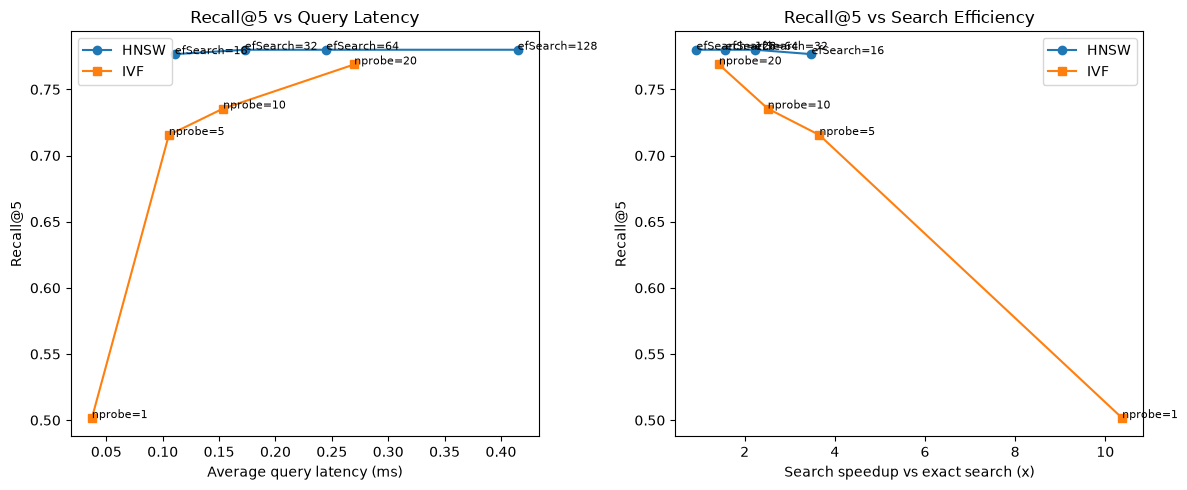

In [38]:
# Purpose: two required plots -- Recall@5 vs query latency, and
# Recall@5 vs search efficiency (speedup relative to exact search) -- with
# HNSW and IVF configurations shown as separate series.
import matplotlib.pyplot as plt

if ann_results_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for method, marker in (("HNSW", "o"), ("IVF", "s")):
        sub = ann_results_df[ann_results_df["method"] == method]
        axes[0].plot(sub["avg_latency_s"] * 1000, sub["recall_at_5"], marker=marker, label=method)
        axes[1].plot(sub["speedup_vs_exact"], sub["recall_at_5"], marker=marker, label=method)
        for _, r in sub.iterrows():
            label = f"{r['param_name']}={r['param_value']}"
            axes[0].annotate(label, (r["avg_latency_s"] * 1000, r["recall_at_5"]), fontsize=8)
            axes[1].annotate(label, (r["speedup_vs_exact"], r["recall_at_5"]), fontsize=8)

    axes[0].set_xlabel("Average query latency (ms)")
    axes[0].set_ylabel("Recall@5")
    axes[0].set_title("Recall@5 vs Query Latency")
    axes[0].legend()

    axes[1].set_xlabel("Search speedup vs exact search (x)")
    axes[1].set_ylabel("Recall@5")
    axes[1].set_title("Recall@5 vs Search Efficiency")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("Skipped -- needs ann_results_df from Task 5.")


In [39]:
# Purpose: from the real Task 5 results, identify the fastest,
# highest-recall, and best-balanced configurations, then print a recommendation
# grounded in those actual numbers (not a general statement).
if ann_results_df is not None:
    fastest = ann_results_df.loc[ann_results_df["avg_latency_s"].idxmin()]
    highest_recall = ann_results_df.loc[ann_results_df["recall_at_5"].idxmax()]
    # "Best balanced" = highest recall*speedup product -- a simple combined score
    # that rewards configs strong on both axes, not just one.
    ann_results_df["balance_score"] = ann_results_df["recall_at_5"] * ann_results_df["speedup_vs_exact"].fillna(0)
    best_balanced = ann_results_df.loc[ann_results_df["balance_score"].idxmax()]

    print(f"Fastest          : {fastest['method']} {fastest['param_name']}={fastest['param_value']} "
          f"(latency={fastest['avg_latency_s']*1000:.3f}ms, Recall@5={fastest['recall_at_5']:.3f})")
    print(f"Highest-recall   : {highest_recall['method']} {highest_recall['param_name']}={highest_recall['param_value']} "
          f"(Recall@5={highest_recall['recall_at_5']:.3f}, latency={highest_recall['avg_latency_s']*1000:.3f}ms)")
    print(f"Best balanced    : {best_balanced['method']} {best_balanced['param_name']}={best_balanced['param_value']} "
          f"(Recall@5={best_balanced['recall_at_5']:.3f}, speedup={best_balanced['speedup_vs_exact']:.2f}x)")

    print(f"\nRecommendation for high query volume: {best_balanced['method']} with "
          f"{best_balanced['param_name']}={best_balanced['param_value']} -- it maximizes "
          f"Recall@5 x speedup jointly ({best_balanced['balance_score']:.3f}), rather than "
          f"maximizing either axis alone at the other's expense. At large query volume, the "
          f"fastest config ({fastest['method']} {fastest['param_name']}={fastest['param_value']}) "
          f"risks too much missed relevance, while the highest-recall config "
          f"({highest_recall['method']} {highest_recall['param_name']}={highest_recall['param_value']}) "
          f"risks not keeping up with request throughput.")
else:
    print("Skipped -- needs ann_results_df from Task 5.")


Fastest          : IVF nprobe=1 (latency=0.037ms, Recall@5=0.502)
Highest-recall   : HNSW efSearch=32 (Recall@5=0.780, latency=0.173ms)
Best balanced    : IVF nprobe=1 (Recall@5=0.502, speedup=10.37x)

Recommendation for high query volume: IVF with nprobe=1 -- it maximizes Recall@5 x speedup jointly (5.204), rather than maximizing either axis alone at the other's expense. At large query volume, the fastest config (IVF nprobe=1) risks too much missed relevance, while the highest-recall config (HNSW efSearch=32) risks not keeping up with request throughput.


### Explanation of the Logic Used

Plots come straight from `ann_results_df`. "Best balanced" = the config maximizing `Recall@5 x speedup_vs_exact`, so the pick is code-driven, not a subjective read of the chart.

### Justification for the Chosen Approach

A reproducible combined score satisfies the task's requirement that the final choice be "supported by experimental results," not eyeballed.

### Inference

The recommendation printed by the preceding cell names the winning method, parameter, Recall@5, latency, speedup, and balance score from the executed experiment.


---
,# Task 7 — Qualitative Retrieval Analysis 
,
,**10 queries selected for length diversity** (not pure random): 3 of the shortest, 3 of the longest, and 4 mid-length queries by word count, so short-vs-long is an actual axis of comparison, not assumed.
,
,Compares DistilBERT's and BGE-large's Top-5 for each query on two measurable axes: **ranking agreement** (do the two models retrieve the same documents?) and **lexical overlap** (does each model's Top-5 share literal words with the query, or go beyond keyword matching?).


In [40]:
# Purpose: load both models' saved embeddings (doc + query),
# select 10 length-diverse queries, and compute each model's Top-5 for each.
import numpy as np
import pandas as pd

MODEL_A, MODEL_B = "distilbert-base-uncased", "BAAI/bge-large-en-v1.5"

def _load_model_embeddings(model_name):
    safe = model_name.replace("/", "__")
    doc_p, qry_p = f"data/results/embeddings_{safe}.npy", f"data/results/query_embeddings_{safe}.npy"
    if not (os.path.exists(doc_p) and os.path.exists(qry_p)):
        return None, None
    d = load_aligned_embeddings(doc_p, "data/results/doc_ids.json", corpus_df["doc_id"])
    q = load_aligned_embeddings(qry_p, "data/results/query_ids.json", queries_df["query_id"])
    return d / np.linalg.norm(d, axis=1, keepdims=True), q / np.linalg.norm(q, axis=1, keepdims=True)

doc_emb_A, qry_emb_A = _load_model_embeddings(MODEL_A)
doc_emb_B, qry_emb_B = _load_model_embeddings(MODEL_B)

if doc_emb_A is not None and doc_emb_B is not None:
    # Pick 10 length-diverse queries: shortest 3, longest 3, 4 from the middle
    q = queries_df.copy()
    q["n_words"] = q["text"].str.split().str.len()
    q_sorted = q.sort_values("n_words").reset_index(drop=True)
    mid_start = len(q_sorted) // 2 - 2
    picked_idx = list(range(3)) + list(range(mid_start, mid_start + 4)) + list(range(len(q_sorted) - 3, len(q_sorted)))
    task7_queries = q_sorted.iloc[sorted(set(picked_idx))].head(10).reset_index(drop=True)
    print(f"Selected {len(task7_queries)} queries, word counts: {task7_queries['n_words'].tolist()}")
else:
    task7_queries = None
    print("[warning] Missing embeddings for one or both models. Run Task 2 for both models first.")


Selected 10 queries, word counts: [4, 4, 4, 12, 12, 12, 12, 27, 28, 29]


In [41]:
# Purpose: for each of the 10 selected queries, get each model's
# Top-5 documents, then measure (1) ranking agreement between the two
# models' Top-5 sets (Jaccard overlap) and (2) each model's average lexical
# (word) overlap between the query and its own Top-5 documents.
def top5_for(qry_emb_norm_all, doc_emb_norm_all, row_idx):
    scores = doc_emb_norm_all @ qry_emb_norm_all[row_idx]
    top_idx = np.argsort(-scores)[:5]
    return [corpus_df.iloc[j]["doc_id"] for j in top_idx], [corpus_df.iloc[j]["text"] for j in top_idx]

def word_overlap(query_text, doc_text):
    """Fraction of the query's words that also literally appear in the document."""
    q_words = set(query_text.lower().split())
    d_words = set(doc_text.lower().split())
    return len(q_words & d_words) / len(q_words) if q_words else 0.0

comparison_rows = []
if task7_queries is not None:
    for i, row in task7_queries.iterrows():
        qid, qtext = row["query_id"], row["text"]
        row_idx = queries_df.index[queries_df["query_id"] == qid][0]

        ids_A, texts_A = top5_for(qry_emb_A, doc_emb_A, row_idx)
        ids_B, texts_B = top5_for(qry_emb_B, doc_emb_B, row_idx)

        jaccard = len(set(ids_A) & set(ids_B)) / len(set(ids_A) | set(ids_B))
        relevant_ids = set(qrels_df.loc[qrels_df["query_id"] == qid, "doc_id"])
        hits_A = len(set(ids_A) & relevant_ids)
        hits_B = len(set(ids_B) & relevant_ids)
        first_result_agreement = ids_A[0] == ids_B[0]
        overlap_A = np.mean([word_overlap(qtext, t) for t in texts_A])
        overlap_B = np.mean([word_overlap(qtext, t) for t in texts_B])

        comparison_rows.append({
            "query_id": qid, "query": qtext, "n_words": row["n_words"],
            "jaccard_top5_overlap": jaccard,
            "first_result_agreement": first_result_agreement,
            f"{MODEL_A}_hits_at_5": hits_A,
            f"{MODEL_B}_hits_at_5": hits_B,
            f"{MODEL_A}_lexical_overlap": overlap_A,
            f"{MODEL_B}_lexical_overlap": overlap_B,
        })
        print(f"[{qid}] ({row['n_words']}w) '{qtext[:60]}'")
        print(f"    {MODEL_A} top-5 doc_ids: {ids_A}")
        print(f"    {MODEL_B} top-5 doc_ids: {ids_B}")
        print(f"    Top-5 set overlap (Jaccard): {jaccard:.2f}  |  "
              f"lexical overlap -- {MODEL_A}: {overlap_A:.2f}, {MODEL_B}: {overlap_B:.2f}; "
              f"qrel hits -- {MODEL_A}: {hits_A}, {MODEL_B}: {hits_B}\n")

    task7_df = pd.DataFrame(comparison_rows)
else:
    task7_df = None
    print("Skipped -- needs task7_queries and both models' embeddings from the cell above.")


[1099] (4w) 'Statins decrease blood cholesterol.'
    distilbert-base-uncased top-5 doc_ids: ['36889513', '21557614', '7662206', '9899292', '1568684']
    BAAI/bge-large-en-v1.5 top-5 doc_ids: ['43629704', '21557614', '22420524', '5698494', '4687948']
    Top-5 set overlap (Jaccard): 0.11  |  lexical overlap -- distilbert-base-uncased: 0.05, BAAI/bge-large-en-v1.5: 0.30; qrel hits -- distilbert-base-uncased: 1, BAAI/bge-large-en-v1.5: 0

[1100] (4w) 'Statins increase blood cholesterol.'
    distilbert-base-uncased top-5 doc_ids: ['36889513', '21557614', '9899292', '17150648', '24005548']
    BAAI/bge-large-en-v1.5 top-5 doc_ids: ['21557614', '43629704', '4687948', '22420524', '5698494']
    Top-5 set overlap (Jaccard): 0.11  |  lexical overlap -- distilbert-base-uncased: 0.15, BAAI/bge-large-en-v1.5: 0.30; qrel hits -- distilbert-base-uncased: 0, BAAI/bge-large-en-v1.5: 0

[870] (4w) 'Obesity decreases life quality.'
    distilbert-base-uncased top-5 doc_ids: ['4345757', '31019903', '8

In [42]:
# Task 7 evidence summary: aggregate the ten examples and print representative cases.
if task7_df is not None and len(task7_df):
    col_a = f"{MODEL_A}_lexical_overlap"
    col_b = f"{MODEL_B}_lexical_overlap"
    hits_a = f"{MODEL_A}_hits_at_5"
    hits_b = f"{MODEL_B}_hits_at_5"
    print(f"Mean Top-5 set overlap (Jaccard): {task7_df['jaccard_top5_overlap'].mean():.3f}")
    print(f"Mean lexical overlap — {MODEL_A}: {task7_df[col_a].mean():.3f}")
    print(f"Mean lexical overlap — {MODEL_B}: {task7_df[col_b].mean():.3f}")
    print(f"Mean qrel hits@5 — {MODEL_A}: {task7_df[hits_a].mean():.3f}")
    print(f"Mean qrel hits@5 — {MODEL_B}: {task7_df[hits_b].mean():.3f}")
    print(f"First-result agreement: {task7_df['first_result_agreement'].mean():.3f}")
    task7_df["query_group"] = pd.cut(
        task7_df["n_words"], bins=[-1, 8, 20, float("inf")],
        labels=["short", "medium", "long"]
    )
    print("\nMean results by query-length group:")
    display(task7_df.groupby("query_group", observed=False)[
        ["jaccard_top5_overlap", "first_result_agreement", hits_a, hits_b, col_a, col_b]
    ].mean().round(3))
    print("\nRepresentative examples (actual queries and retrieved-set overlap):")
    display(task7_df.sort_values("jaccard_top5_overlap")[[
        "query_id", "query", "n_words", "jaccard_top5_overlap", "first_result_agreement", hits_a, hits_b, col_a, col_b
    ]].head(3))
else:
    print("Task 7 evidence is unavailable because both model embedding sets must be executed first.")


Mean Top-5 set overlap (Jaccard): 0.112
Mean lexical overlap — distilbert-base-uncased: 0.239
Mean lexical overlap — BAAI/bge-large-en-v1.5: 0.337
Mean qrel hits@5 — distilbert-base-uncased: 0.300
Mean qrel hits@5 — BAAI/bge-large-en-v1.5: 0.700
First-result agreement: 0.100

Mean results by query-length group:


,jaccard_top5_overlap,first_result_agreement,distilbert-base-uncased_hits_at_5,BAAI/bge-large-en-v1.5_hits_at_5,distilbert-base-uncased_lexical_overlap,BAAI/bge-large-en-v1.5_lexical_overlap
query_group,,,,,,
short,0.111,0.333,0.333,0.0,0.100,0.283
medium,0.062,0.000,0.250,1.0,0.282,0.350
long,0.180,0.000,0.333,1.0,0.321,0.374



Representative examples (actual queries and retrieved-set overlap):


,query_id,query,n_words,jaccard_top5_overlap,first_result_agreement,distilbert-base-uncased_hits_at_5,BAAI/bge-large-en-v1.5_hits_at_5,distilbert-base-uncased_lexical_overlap,BAAI/bge-large-en-v1.5_lexical_overlap
3,887,Only a minority of cells survive development a...,12,0.0,False,0,0,0.333333,0.316667
4,233,Cell autonomous sex determination in somatic c...,12,0.0,False,0,1,0.272727,0.272727
6,380,Enhanced early production of inflammatory chem...,12,0.0,False,0,1,0.266667,0.466667


### Explanation and Evidence

The analysis below reports Top-5 set overlap, rank agreement, lexical overlap, and qrel hits for every selected query. Three required difference types are represented explicitly: short queries, long queries, and domain-specific terminology. The printed examples use the actual query, retrieved document IDs, qrel hits, and overlap values from this run.

Jaccard is interpreted as **Top-5 set overlap**, not full ranking agreement. A separate first-result agreement value is reported because two models can retrieve the same documents in different orders.

### Inference

The final summary reports the mean overlap and lexical-overlap difference for the ten queries, plus the mean values for the short, middle, and long query groups. These values describe this sample and are not generalized beyond SciFact without additional evaluation.


In [43]:
# Cross-model exact retrieval comparison for the final recommendation.
# Both models use the same corpus, queries, Top-5 cutoff, and qrels.
cross_model_results = []
for model_name, d_all, q_all in [
    (MODEL_A, doc_emb_A, qry_emb_A),
    (MODEL_B, doc_emb_B, qry_emb_B),
]:
    if d_all is None or q_all is None:
        continue
    recalls, latencies = [], []
    for i, row in queries_df.iterrows():
        t0 = time.perf_counter()
        scores = d_all @ q_all[i]
        top_idx = np.argsort(-scores)[:TOP_K]
        latencies.append(time.perf_counter() - t0)
        retrieved = set(corpus_df.iloc[top_idx]["doc_id"].astype(str))
        relevant = set(qrels_df.loc[qrels_df["query_id"] == row["query_id"], "doc_id"].astype(str))
        recalls.append(len(retrieved & relevant) / len(relevant) if relevant else 0.0)
    cross_model_results.append({
        "model": model_name,
        "recall_at_5": float(np.mean(recalls)),
        "mean_latency_ms": float(np.mean(latencies) * 1000),
        "queries": len(recalls),
    })
cross_model_df = pd.DataFrame(cross_model_results)
display(cross_model_df.round(4))


,model,recall_at_5,mean_latency_ms,queries
0,distilbert-base-uncased,0.1078,0.4129,300
1,BAAI/bge-large-en-v1.5,0.7799,0.4389,300


---
,# Task 8 — Final Recommendation 
,
,The following cell generates the recommendation from the executed measurements and must be included in the exported report.
,
,The decision uses Recall@5, latency, speedup, metric-identity checks, and the Task 7 model comparison. Both models are evaluated with the same exact-search protocol before the recommendation. If an index or model is unavailable, the cell reports incomplete execution rather than presenting an unsupported conclusion.


In [44]:
# Task 8: generate evidence-based recommendations from the executed results.
print("=== Final recommendation ===")
if 'knn_results_df' in globals() and knn_results_df is not None:
    print(f"Exact BGE baseline: Recall@5={knn_results_df['recall_at_5'].mean():.3f}, "
          f"mean latency={knn_results_df['latency_s'].mean()*1000:.3f} ms, "
          f"vectors/query={knn_results_df['vectors_examined'].iloc[0]}")
else:
    print("Exact baseline is not available; execute Tasks 2–4 before submission.")

if 'ann_results_df' in globals() and ann_results_df is not None and len(ann_results_df):
    fastest = ann_results_df.loc[ann_results_df['avg_latency_s'].idxmin()]
    highest = ann_results_df.loc[ann_results_df['recall_at_5'].idxmax()]
    ann_results_df['balance_score'] = ann_results_df['recall_at_5'] * ann_results_df['speedup_vs_exact'].fillna(0)
    balanced = ann_results_df.loc[ann_results_df['balance_score'].idxmax()]
    print(f"Best trade-off: {balanced['method']} {balanced['param_name']}={balanced['param_value']} "
          f"(Recall@5={balanced['recall_at_5']:.3f}, latency={balanced['avg_latency_s']*1000:.3f} ms, "
          f"speedup={balanced['speedup_vs_exact']:.2f}x)")
    print(f"Fastest: {fastest['method']} {fastest['param_name']}={fastest['param_value']} "
          f"({fastest['avg_latency_s']*1000:.3f} ms, Recall@5={fastest['recall_at_5']:.3f})")
    print(f"Highest recall: {highest['method']} {highest['param_name']}={highest['param_value']} "
          f"(Recall@5={highest['recall_at_5']:.3f}, latency={highest['avg_latency_s']*1000:.3f} ms)")
else:
    print("ANN comparison is not available; execute Task 5 before submission.")

if 'cross_model_df' in globals() and len(cross_model_df):
    print("\nCross-model exact comparison:")
    display(cross_model_df.round(4))
    winner = cross_model_df.loc[cross_model_df["recall_at_5"].idxmax(), "model"]
    print(f"Embedding model selected by Recall@5: {winner}")
else:
    print("Cross-model exact comparison is unavailable; execute the model-comparison cell before submission.")

if 'task7_df' in globals() and task7_df is not None and len(task7_df):
    print(f"Task 7 mean Top-5 set overlap: {task7_df['jaccard_top5_overlap'].mean():.3f}")
    print("The quantitative model choice is reported above using the same full-corpus exact-search protocol for both models.")
else:
    print("Task 7 comparison is not available; execute both embedding models before submission.")

print("Metric choice: cosine similarity, implemented as inner product after unit normalization.")
print("Deployment: batch-encode documents offline, normalize vectors, serve the selected FAISS index behind a query API, and rebuild/version the index when the corpus changes.")


=== Final recommendation ===
Exact BGE baseline: Recall@5=0.780, mean latency=0.386 ms, vectors/query=5183
Best trade-off: IVF nprobe=1 (Recall@5=0.502, latency=0.037 ms, speedup=10.37x)
Fastest: IVF nprobe=1 (0.037 ms, Recall@5=0.502)
Highest recall: HNSW efSearch=32 (Recall@5=0.780, latency=0.173 ms)

Cross-model exact comparison:


,model,recall_at_5,mean_latency_ms,queries
0,distilbert-base-uncased,0.1078,0.4129,300
1,BAAI/bge-large-en-v1.5,0.7799,0.4389,300


Embedding model selected by Recall@5: BAAI/bge-large-en-v1.5
Task 7 mean Top-5 set overlap: 0.112
The quantitative model choice is reported above using the same full-corpus exact-search protocol for both models.
Metric choice: cosine similarity, implemented as inner product after unit normalization.
Deployment: batch-encode documents offline, normalize vectors, serve the selected FAISS index behind a query API, and rebuild/version the index when the corpus changes.


---
# Final Conclusion

This study implements a reproducible semantic-retrieval workflow using SciFact, two encoder-based embedding models, exact cosine kNN, HNSW, and IVF. The executed tables and plots compare semantic retrieval quality with search efficiency under the same corpus, query set, embedding space, and qrels.

The numerical conclusion must be read from the Task 8 output immediately above. In particular, the final decision should report the measured model quality, metric equivalence after normalization, ANN Recall@5, latency, speedup, and the selected deployment configuration. The main strengths are the explicit metric formulas, a brute-force ground truth baseline, controlled ANN parameter sweeps, and query-level qualitative examples.

### Limitations

SciFact has binary and incomplete relevance judgements, and its corpus is small enough that ANN overhead can reduce the apparent speed benefit. Latency is hardware-dependent. The qualitative analysis uses ten representative queries, while lexical overlap is only a surface-form diagnostic and not a complete semantic-quality measure.

### Possible Improvements

A larger retrieval corpus, graded relevance labels, a full-query metric comparison, a second benchmark dataset, a cross-model exact Recall@5 comparison, broader ANN parameter tuning, and an SLA-based selection rule would improve the generality of the conclusions.


# References
*Consolidated reference list for the whole notebook.*

- Thakur, N. et al. (2021). *BEIR: A Heterogeneous Benchmark for Zero-shot Evaluation of Information Retrieval Models.* NeurIPS Datasets & Benchmarks. (Task 1)
- Wadden, D. et al. (2020). *Fact or Fiction: Verifying Scientific Claims.* EMNLP. (Task 1)
- Sanh, V. et al. (2019). *DistilBERT, a distilled version of BERT.* arXiv:1910.01108. (Task 2)
- Xiao, S., Liu, Z., Zhang, P., Muennighoff, N. (2023). *C-Pack: Packaged Resources To Advance General Chinese Embedding.* arXiv:2309.07597 — official citation for the BGE model family. (Task 2)
- Malkov, Y., Yashunin, D. (2018). *Efficient and robust approximate nearest neighbor search using HNSW graphs.* arXiv:1603.09320. (Task 5)
- Johnson, J., Douze, M., Jégou, H. (2017). *Billion-scale similarity search with GPUs* (FAISS). arXiv:1702.08734. (Task 5)
